# PPO-beam vs Greedy — solving-path comparison

Simple comparison of the solving paths found by **PPO + beam search** (the pilot we just ran)
against the **greedy-search** baseline (GS-Sub), over all 17,635 presentations.

Three questions:
1. **Path length** — how often is beam's path shorter than greedy's, and by how much?
2. **Temporary length increases ("humps")** — how often does a path let the total relator
   length *rise above the start* before trivializing, by how much, and how many times? Beam vs greedy.
3. **Does the detour help?** — is climbing a hump associated with shorter solutions / new solves?

Local, **numpy/pandas/matplotlib only** (no JAX). Beam paths are stored as packed action ints;
we replay them to states with the pure-numpy `scripts/s_move_np.py` port of the env S-move.

## 2. Setup & load

In [14]:
import os, sys, json, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# find repo root (walk up until scripts/s_move_np.py + data/ exist)
root = os.path.abspath('.')
while root != '/' and not (os.path.exists(os.path.join(root, 'scripts', 's_move_np.py'))
                           and os.path.isdir(os.path.join(root, 'data'))):
    root = os.path.dirname(root)
assert os.path.exists(os.path.join(root, 'scripts', 's_move_np.py')), 'repo root not found'
sys.path.insert(0, os.path.join(root, 'scripts'))
import s_move_np  # pure-numpy beam replay (no jax)
DATA = os.path.join(root, 'data')
print('repo root:', root)

# --- index (one row per presentation: greedy/beam solved flags + path lengths) ---
df = pd.read_csv(os.path.join(DATA, 'merged_best_paths_index.csv'))
for c in ['greedy_solved', 'beam_solved', 'solved']:
    df[c] = df[c].astype(str).isin(['True', 'true', '1'])
initial = {int(r.idx): (r.r1, r.r2) for r in df.itertuples()}

# --- greedy solving paths (state trajectories) straight from the GS CSV ---
csv.field_size_limit(10 ** 7)
greedy_paths = {}  # idx -> [r1_0, r2_0, r1_1, r2_1, ...]
with open(os.path.join(DATA, 'all_presentations_len_8_to_19_GS_solved_copy2.csv'), newline='') as f:
    rd = csv.reader(f); next(rd)
    for i, row in enumerate(rd):
        if not row or all(c.strip() == '' for c in row):
            continue
        if int(row[3]) >= 0:  # Path Length >= 0 -> greedy solved
            greedy_paths[i] = [t.strip() for t in row[4:] if t.strip() != '']

# --- beam packed paths (winning per idx) from the pilot ---
beam_packed = {}  # idx -> [packed action ints]
with open(os.path.join(DATA, 'pilot_results.jsonl')) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        r = json.loads(line)
        if r.get('beam_solved') and r.get('packed_path'):
            beam_packed[r['idx']] = r['packed_path']  # last record wins

both_idx = df.index[df.greedy_solved & df.beam_solved].tolist()
print(f'total presentations : {len(df)}')
print(f'greedy solved       : {int(df.greedy_solved.sum())}')
print(f'beam   solved       : {int(df.beam_solved.sum())}')
print(f'solved by either    : {int(df.solved.sum())}')
print(f'both                : {len(both_idx)}')
print(f'beam-only (new)     : {int((~df.greedy_solved & df.beam_solved).sum())}')
print(f'greedy-only         : {int((df.greedy_solved & ~df.beam_solved).sum())}')

repo root: /Users/avigyapaudel/Documents/Obsidian Vault/surf/codebase/ACSolverX
total presentations : 17635
greedy solved       : 12681
beam   solved       : 12670
solved by either    : 12681
both                : 12670
beam-only (new)     : 0
greedy-only         : 11


## 3. Path length: beam vs greedy (both-solved)

For presentations solved by **both**, compare the number of moves. `delta = greedy_len - beam_len`
(positive = beam is shorter).

both-solved presentations : 12670
  beam shorter :  7290  (57.5%)
  equal        :  3914  (30.9%)
  beam longer  :  1466  (11.6%)
mean  moves   greedy 14.85  | beam 10.82
median moves  greedy     9  | beam     8
total moves   greedy 188089  | beam 137051   (beam saves 51,038 moves, 27.1%)
when beam shorter: mean saving 7.28 moves, max 78


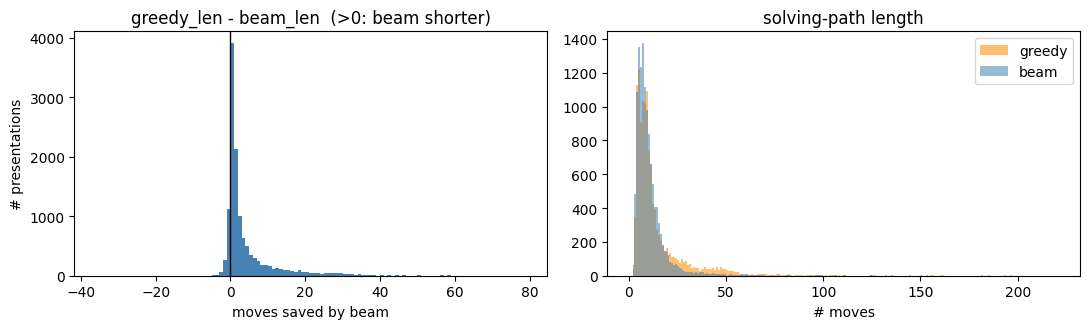

In [15]:
b = df[df.greedy_solved & df.beam_solved].copy()
g_len = b.greedy_path_length.values
k_len = b.beam_path_length.values
delta = g_len - k_len

n = len(b)
n_short = int((delta > 0).sum()); n_eq = int((delta == 0).sum()); n_long = int((delta < 0).sum())
print(f'both-solved presentations : {n}')
print(f'  beam shorter : {n_short:5d}  ({100*n_short/n:4.1f}%)')
print(f'  equal        : {n_eq:5d}  ({100*n_eq/n:4.1f}%)')
print(f'  beam longer  : {n_long:5d}  ({100*n_long/n:4.1f}%)')
print(f'mean  moves   greedy {g_len.mean():5.2f}  | beam {k_len.mean():5.2f}')
print(f'median moves  greedy {np.median(g_len):5.0f}  | beam {np.median(k_len):5.0f}')
print(f'total moves   greedy {g_len.sum():6d}  | beam {k_len.sum():6d}'
      f'   (beam saves {g_len.sum()-k_len.sum():,} moves, {100*(g_len.sum()-k_len.sum())/g_len.sum():.1f}%)')
print(f'when beam shorter: mean saving {delta[delta>0].mean():.2f} moves, max {delta.max()}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
lo, hi = int(delta.min()), int(delta.max())
ax[0].hist(delta, bins=range(lo, hi + 2), color='steelblue', edgecolor='none')
ax[0].axvline(0, color='k', lw=1)
ax[0].set_title('greedy_len - beam_len  (>0: beam shorter)')
ax[0].set_xlabel('moves saved by beam'); ax[0].set_ylabel('# presentations')
mx = max(g_len.max(), k_len.max())
ax[1].hist(g_len, bins=range(0, mx + 2), alpha=0.55, label='greedy', color='darkorange')
ax[1].hist(k_len, bins=range(0, mx + 2), alpha=0.55, label='beam', color='steelblue')
ax[1].set_title('solving-path length'); ax[1].set_xlabel('# moves'); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Build length trajectories (greedy from CSV, beam by replay)

Along a solving path the **total relator length** `len(r1)+len(r2)` rises and falls. We track it
step-by-step. Greedy trajectories come straight from the CSV states; beam trajectories are obtained
by replaying the packed actions with `s_move_np` (this also re-verifies every beam path trivializes).

In [16]:
def traj_lengths(flat):
    """[r1_0,r2_0,r1_1,r2_1,...] -> array of total relator length per state."""
    return np.array([len(flat[i]) + len(flat[i + 1]) for i in range(0, len(flat), 2)], dtype=int)

def hump_stats(L):
    """Length trajectory -> dict of hump metrics (relative to the START length)."""
    L = np.asarray(L)
    ups = L[1:] - L[:-1]
    return {'init': int(L[0]), 'maxlen': int(L.max()),
            'hump': int(L.max() - L[0]),            # how high above the start it climbs
            'n_up': int((ups > 0).sum()),            # how many length-increasing moves
            'up_total': int(ups[ups > 0].sum()),     # total length added across up-moves
            'max_up': int(ups.max()) if len(ups) else 0,
            'nsteps': int(len(L) - 1)}

# greedy trajectories (all greedy-solved)
greedy_traj = {idx: traj_lengths(toks) for idx, toks in greedy_paths.items()}

# beam trajectories (replay packed actions); restrict to both-solved for fair pairing
beam_traj = {}
fails = 0
for j, idx in enumerate(both_idx):
    r1, r2 = initial[idx]
    flat, term, nsteps = s_move_np.replay_to_states(r1, r2, beam_packed[idx])
    if not term:
        fails += 1; continue
    beam_traj[idx] = traj_lengths(flat)
    if (j + 1) % 3000 == 0:
        print(f'  replayed {j+1}/{len(both_idx)} beam paths...')
print(f'greedy trajectories: {len(greedy_traj)}   beam trajectories: {len(beam_traj)}   replay fails: {fails}')

# paired stats table over both-solved
rows = []
for idx in both_idx:
    if idx not in beam_traj:
        continue
    g = hump_stats(greedy_traj[idx]); k = hump_stats(beam_traj[idx])
    rows.append({'idx': idx,
                 'g_len': g['nsteps'], 'k_len': k['nsteps'],
                 'g_init': g['init'], 'k_init': k['init'],
                 'g_hump': g['hump'], 'k_hump': k['hump'],
                 'g_nup': g['n_up'], 'k_nup': k['n_up'],
                 'g_max': g['maxlen'], 'k_max': k['maxlen']})
H = pd.DataFrame(rows).set_index('idx')
H['delta_len'] = H.g_len - H.k_len   # >0 beam shorter
print('paired table:', H.shape)
H.head()

  replayed 3000/12670 beam paths...
  replayed 6000/12670 beam paths...
  replayed 9000/12670 beam paths...
  replayed 12000/12670 beam paths...
greedy trajectories: 12681   beam trajectories: 12670   replay fails: 0
paired table: (12670, 11)


,g_len,k_len,g_init,k_init,g_hump,k_hump,g_nup,k_nup,g_max,k_max,delta_len
idx,,,,,,,,,,,
0,4,3,10,10,0,0,0,0,10,10,1
1,5,4,10,10,1,5,1,2,11,15,1
2,5,4,10,10,0,5,0,2,10,15,1
3,3,3,10,10,0,0,0,0,10,10,0
4,4,4,11,11,0,0,0,0,11,11,0


## 5. How high does the word length climb? (greedy vs beam)

A **"hump"** = the path temporarily makes the two words **longer** before shrinking them down to the
trivial pair. We measure each path's hump as

> **hump = (longest total length reached on the path) − (start length)**

i.e. *how much* the words grow at their tallest point — **not** *how many times* they grow. Below we
bucket that height (0, 1–2, 3–5, 6–10, 11+ extra letters) and count how many presentations fall in each
bucket, greedy vs beam.

over 12670 presentations solved by BOTH methods:
  greedy never grows the words (hump 0):  9316  (74%)
  beam   never grows the words (hump 0):  5109  (40%)
  climb 11+ extra letters             : greedy 9,  beam 1173


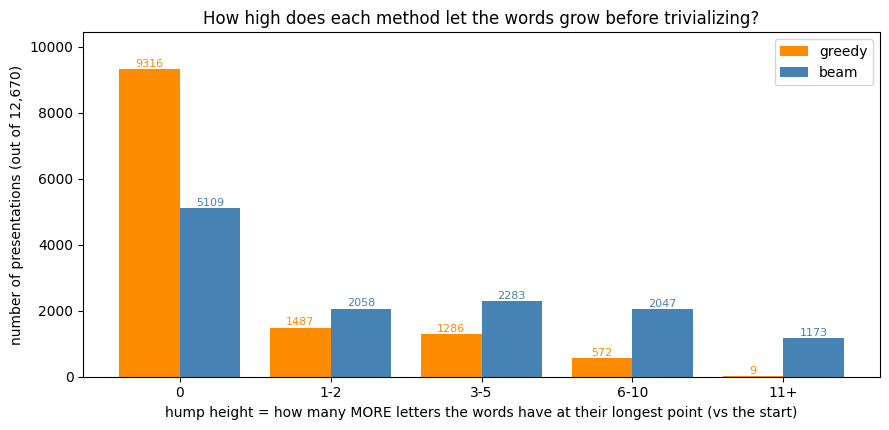

In [17]:
# bucket each path's hump height (0, 1-2, 3-5, 6-10, 11+) and COUNT presentations
LAB = ['0', '1-2', '3-5', '6-10', '11+']
def bucketize(v):
    return pd.cut(v, bins=[-1, 0, 2, 5, 10, 10 ** 6], labels=LAB)
H['g_bucket'] = bucketize(H.g_hump)
H['k_bucket'] = bucketize(H.k_hump)
g_cnt = H.g_bucket.value_counts().reindex(LAB)
k_cnt = H.k_bucket.value_counts().reindex(LAB)
ntot = len(H)

print(f'over {ntot} presentations solved by BOTH methods:')
print(f"  greedy never grows the words (hump 0): {int(g_cnt['0']):5d}  ({100*g_cnt['0']/ntot:.0f}%)")
print(f"  beam   never grows the words (hump 0): {int(k_cnt['0']):5d}  ({100*k_cnt['0']/ntot:.0f}%)")
print(f"  climb 11+ extra letters             : greedy {int(g_cnt['11+'])},  beam {int(k_cnt['11+'])}")

x = np.arange(len(LAB)); w = 0.4
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x - w / 2, g_cnt.values, w, color='darkorange', label='greedy')
ax.bar(x + w / 2, k_cnt.values, w, color='steelblue', label='beam')
for xi, (gv, kv) in enumerate(zip(g_cnt.values, k_cnt.values)):
    ax.text(xi - w / 2, gv + 70, str(int(gv)), ha='center', fontsize=8, color='darkorange')
    ax.text(xi + w / 2, kv + 70, str(int(kv)), ha='center', fontsize=8, color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(LAB)
ax.set_xlabel('hump height = how many MORE letters the words have at their longest point (vs the start)')
ax.set_ylabel('number of presentations (out of 12,670)')
ax.set_title('How high does each method let the words grow before trivializing?')
ax.set_ylim(0, max(g_cnt.max(), k_cnt.max()) * 1.12)
ax.legend(); plt.tight_layout(); plt.show()

**What this figure shows.** Each pair of bars is one hump-height bucket; bar height = how many of the
12,670 both-solved presentations had a hump of that size (orange = greedy, blue = beam).

**What you can see.** Greedy almost never grows the words: **9,316 (74%)** of its paths have hump 0 (pure
downhill), and only **9** ever climb 11+ extra letters. Beam is the opposite — only **5,109 (40%)** stay
flat, and **1,173** climb 11+ letters. **Suggests:** beam is far more willing to make the words temporarily
longer. The next figure tests whether that willingness actually helps it solve in fewer moves.

## 5b. Does climbing higher help solve sooner?

Same 12,670 presentations, now grouped by **how high beam climbs** (its hump). For each group we show the
**average number of moves beam saves vs greedy** — the same "moves saved" quantity from `## 3.` — and how
often beam's path is the shorter one. If taller humps line up with bigger savings, the temporary length
increase is *helping* the search trivialize sooner.

how high beam climbs   ->   moves it saves vs greedy:
  hump 0    :  5109 presentations | avg   0.40 moves saved | beam shorter 33.4% of the time
  hump 1-2  :  2058 presentations | avg   1.51 moves saved | beam shorter 59.4% of the time
  hump 3-5  :  2283 presentations | avg   2.62 moves saved | beam shorter 67.3% of the time
  hump 6-10 :  2047 presentations | avg   8.93 moves saved | beam shorter 82.8% of the time
  hump 11+  :  1173 presentations | avg  18.44 moves saved | beam shorter 96.5% of the time


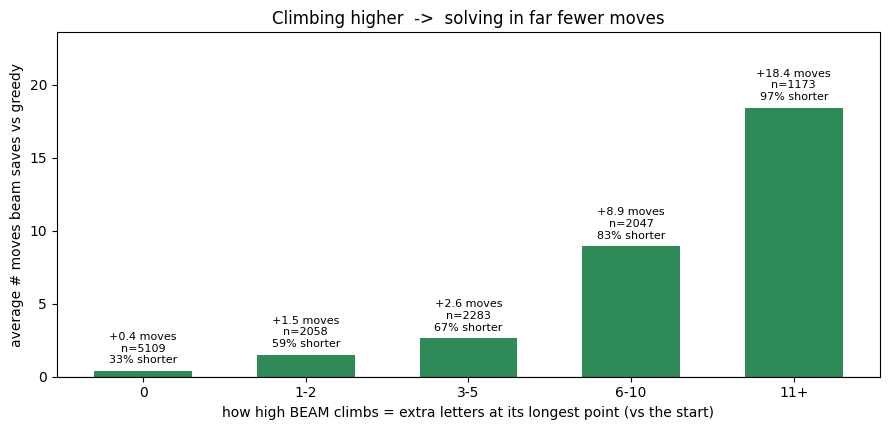

In [18]:
# group presentations by how high BEAM climbs, then average the moves it saves vs greedy
grp = H.groupby('k_bucket', observed=True)['delta_len']
mean_saved = grp.mean().reindex(LAB)
counts = grp.size().reindex(LAB)
pct_shorter = grp.apply(lambda d: 100 * (d > 0).mean()).reindex(LAB)

print('how high beam climbs   ->   moves it saves vs greedy:')
for L in LAB:
    print(f"  hump {L:5s}: {int(counts[L]):5d} presentations | avg {mean_saved[L]:6.2f} moves saved"
          f" | beam shorter {pct_shorter[L]:4.1f}% of the time")

x = np.arange(len(LAB))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x, mean_saved.values, 0.6, color='seagreen')
for xi, L in enumerate(LAB):
    ax.text(xi, mean_saved[L] + 0.4, f"+{mean_saved[L]:.1f} moves\nn={int(counts[L])}\n{pct_shorter[L]:.0f}% shorter",
            ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(LAB)
ax.set_xlabel('how high BEAM climbs = extra letters at its longest point (vs the start)')
ax.set_ylabel('average # moves beam saves vs greedy')
ax.set_title('Climbing higher  ->  solving in far fewer moves')
ax.set_ylim(0, mean_saved.max() * 1.28)
plt.tight_layout(); plt.show()

**What this figure shows.** Each bar is a group of presentations, split by how high beam climbed. Bar
height = the average number of moves beam saved vs greedy on those presentations; the label also gives the
group size `n` and how often beam's path was the shorter one.

**What you can see.** A clear, steady climb. When beam keeps the words flat (hump 0) it barely beats greedy
(**+0.4 moves**, shorter only 33% of the time). The higher it climbs, the bigger the payoff — up to
**+18.4 moves saved and shorter 96% of the time** when it climbs 11+ extra letters. Because each
presentation is compared against greedy on the *same* starting problem, this isn't just "harder problems
behaving differently."

**What it suggests.** The temporary length increase is the *mechanism* by which beam trivializes sooner —
not a side effect. A search that refuses to grow the words (greedy, or any pure relator-length heuristic)
leaves most of these savings on the table. That is exactly why we want a learned distance heuristic
`f(presentation) -> distance` that understands a *longer* state can be *closer* to trivial. The `## 7.`
example (idx 14762) is one concrete case: beam climbs to length 27 and finishes in 126 moves, while greedy
stays low and takes 204.

## 5c. Measuring the climb from any low point, not just the start

Everything above measures a hump as **peak − start length**. But a path often *descends first, then climbs
back up* out of a valley — and a big climb that stays below the start length is **invisible** to
"peak − start." The honest "from any point" measure is the **maximum run-up**:

> **max run-up = the biggest rise from the lowest length reached *so far* up to a later peak.**

(The mirror image of "maximum drawdown" in finance.) It is always ≥ the start-hump, and strictly larger
whenever the path dipped below the start before climbing. Below is the same kind of bar chart as `## 5.`,
but bucketed by max run-up instead.

In [ ]:
# climb features from the already-built trajectories (no beam re-replay needed)
def climb_feats(L):
    """(max run-up, biggest single continuous climb, number of separate climbs)."""
    L = np.asarray(L)
    runup = int((L - np.minimum.accumulate(L)).max())   # rise above the lowest-so-far
    d = np.diff(L); biggest = cur = nclimb = 0; inrun = False
    for x in d:
        if x > 0:
            cur += int(x)
            if not inrun:
                nclimb += 1; inrun = True
        else:
            biggest = max(biggest, cur); cur = 0; inrun = False
    biggest = max(biggest, cur)
    return runup, biggest, nclimb

for who, traj in [('g', greedy_traj), ('k', beam_traj)]:
    f = [climb_feats(traj[i]) for i in H.index]
    H[f'{who}_runup'] = [a for a, _, _ in f]
    H[f'{who}_big']   = [b for _, b, _ in f]
    H[f'{who}_nc']    = [c for _, _, c in f]

print(f'max run-up (mean): greedy {H.g_runup.mean():.2f}  beam {H.k_runup.mean():.2f}'
      f'    (vs start-hump {H.g_hump.mean():.2f} / {H.k_hump.mean():.2f})')
print(f'biggest climb hidden BELOW the start length: greedy {100*(H.g_runup>H.g_hump).mean():.0f}%'
      f'   beam {100*(H.k_runup>H.k_hump).mean():.0f}%')

g_ru = pd.cut(H.g_runup, [-1, 0, 2, 5, 10, 10 ** 6], labels=LAB).value_counts().reindex(LAB)
k_ru = pd.cut(H.k_runup, [-1, 0, 2, 5, 10, 10 ** 6], labels=LAB).value_counts().reindex(LAB)
x = np.arange(len(LAB)); w = 0.4
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x - w / 2, g_ru.values, w, color='darkorange', label='greedy')
ax.bar(x + w / 2, k_ru.values, w, color='steelblue', label='beam')
for xi, (gv, kv) in enumerate(zip(g_ru.values, k_ru.values)):
    ax.text(xi - w / 2, gv + 70, str(int(gv)), ha='center', fontsize=8, color='darkorange')
    ax.text(xi + w / 2, kv + 70, str(int(kv)), ha='center', fontsize=8, color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(LAB)
ax.set_xlabel('max run-up = biggest rise from the lowest point reached so far (extra letters)')
ax.set_ylabel('number of presentations (out of 12,670)')
ax.set_title('Biggest climb measured from ANY valley (not just the start)')
ax.set_ylim(0, max(g_ru.max(), k_ru.max()) * 1.12); ax.legend()
plt.tight_layout(); plt.show()

**What this figure shows.** Same bars as `## 5.`, but the climb is now measured from the lowest point so
far — so a climb *out of a valley* counts even when the path never rises above its start.

**What you can see.** The whole distribution shifts up vs `## 5.`: greedy's average climb nearly doubles
(0.9 → 1.6), and **~44% of greedy paths (38% of beam) have their biggest climb hidden below the start** —
they go down, then have to climb back up. So even greedy, which looked almost flat in `## 5.`, does climb
locally; beam just climbs far more. (Max run-up predicts moves-saved about as strongly as start-hump,
corr +0.64 — the next examples show why this view matters.)

## 5d. Big commitments vs small nibbles — the size of each climb

Two paths can climb the same total amount in very different ways: many tiny steps, or a few big ones. Here
we look at **(left)** how big a single uphill move is when a method *does* increase the length, and
**(right)** the biggest single *continuous* climb on a path.

In [ ]:
# per-move uphill jump sizes, pooled across all paths
g_up = np.concatenate([np.diff(greedy_traj[i]) for i in H.index]); g_up = g_up[g_up > 0]
b_up = np.concatenate([np.diff(beam_traj[i]) for i in H.index]); b_up = b_up[b_up > 0]
SZ = ['+1', '+2', '+3', '+4', '+5 or more']
def share(u):
    return np.array([(u == 1).mean(), (u == 2).mean(), (u == 3).mean(),
                     (u == 4).mean(), (u >= 5).mean()]) * 100
gs, bs = share(g_up), share(b_up)
print(f'single uphill move:  greedy mean +{g_up.mean():.2f} (max +{int(g_up.max())})'
      f'    beam mean +{b_up.mean():.2f} (max +{int(b_up.max())})')
print(f'biggest single continuous climb (avg):  greedy {H.g_big.mean():.2f}   beam {H.k_big.mean():.2f}')
print(f'number of separate climbs per path (avg): greedy {H.g_nc.mean():.2f}   beam {H.k_nc.mean():.2f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(SZ)); w = 0.4
ax[0].bar(x - w / 2, gs, w, color='darkorange', label='greedy')
ax[0].bar(x + w / 2, bs, w, color='steelblue', label='beam')
ax[0].set_xticks(x); ax[0].set_xticklabels(SZ)
ax[0].set_xlabel('size of a single uphill move (extra letters added in one move)')
ax[0].set_ylabel('% of all uphill moves')
ax[0].set_title('When length goes up, by how much in one move?'); ax[0].legend()
vals = [H.g_big.mean(), H.k_big.mean()]
ax[1].bar([0, 1], vals, 0.6, color=['darkorange', 'steelblue'])
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(['greedy', 'beam'])
ax[1].set_ylabel('extra letters in the biggest continuous climb')
ax[1].set_title('Biggest single climb on a path (avg)')
for xi, v in enumerate(vals):
    ax[1].text(xi, v + 0.05, f'{v:.2f}', ha='center')
ax[1].set_ylim(0, max(vals) * 1.2)
plt.tight_layout(); plt.show()

**What this figure shows.** Left: of all the moves that increase the length, what fraction raise it by +1,
+2, … (greedy vs beam). Right: the average size of the single biggest *uninterrupted* climb on a path.

**What you can see.** Greedy *nibbles* — 69% of its uphill moves are just +1, and its biggest climb averages
only ~1.5 letters (spread over ~2.8 separate little climbs). Beam *commits* — 40% of its uphill moves are
+3 or more (single jumps up to +13), and its biggest continuous climb averages ~3.8 letters in *fewer*
(~2.0) climbs.

**What it suggests.** Beam's edge isn't only climbing more often — it makes larger, decisive length
increases in one go, the kind a strict length-reducer would never take.

## 6. Does the detour help?

Two cuts. **(a)** Among both-solved, are beam paths that climb a hump the ones that come out *shorter*
than greedy? **(b)** Did beam solve anything greedy could not (where a detour would be the only route)?

In [19]:
# (a) hump vs being shorter than greedy
beam_wins = H[H.delta_len > 0]   # beam strictly shorter
beam_ties = H[H.delta_len == 0]
beam_loss = H[H.delta_len < 0]   # beam longer
for tag, sub in [('beam shorter', beam_wins), ('tie', beam_ties), ('beam longer', beam_loss)]:
    print(f'{tag:13s} n={len(sub):5d} | beam hump>0: {100*(sub.k_hump>0).mean():4.1f}%'
          f' mean hump {sub.k_hump.mean():4.2f} | mean moves saved {sub.delta_len.mean():+5.2f}')
print()
# correlation: bigger beam hump <-> more moves saved vs greedy?
print(f'corr(beam hump, moves saved vs greedy) = {np.corrcoef(H.k_hump, H.delta_len)[0,1]:+.3f}')
print(f'corr(beam up-moves, moves saved)       = {np.corrcoef(H.k_nup, H.delta_len)[0,1]:+.3f}')
print()
# (b) new solves
new = int((~df.greedy_solved & df.beam_solved).sum())
print(f'(b) presentations beam solved that greedy did NOT: {new}')
if new == 0:
    print('    -> on this pilot beam found NO new solutions; its value here is SHORTER paths, not new ones.')
    print('       (the 11 greedy-only cases are beam timeouts, not greedy-unique solves.)')

beam shorter  n= 7290 | beam hump>0: 76.6% mean hump 4.99 | mean moves saved +7.28
tie           n= 3914 | beam hump>0: 29.4% mean hump 0.91 | mean moves saved +0.00
beam longer   n= 1466 | beam hump>0: 56.2% mean hump 2.34 | mean moves saved -1.37

corr(beam hump, moves saved vs greedy) = +0.663
corr(beam up-moves, moves saved)       = +0.766

(b) presentations beam solved that greedy did NOT: 0
    -> on this pilot beam found NO new solutions; its value here is SHORTER paths, not new ones.
       (the 11 greedy-only cases are beam timeouts, not greedy-unique solves.)


## 7. One concrete example

Total-length trajectory for a single presentation where beam is shorter than greedy and takes a hump —
the clearest single picture of "go uphill, then trivialize".

idx 14762:  start = ('xxyxYXy', 'xxxxyyyXYY')  start length 17
  greedy: 204 moves, max length 23, hump 6
  beam  : 126 moves, max length 27, hump 10


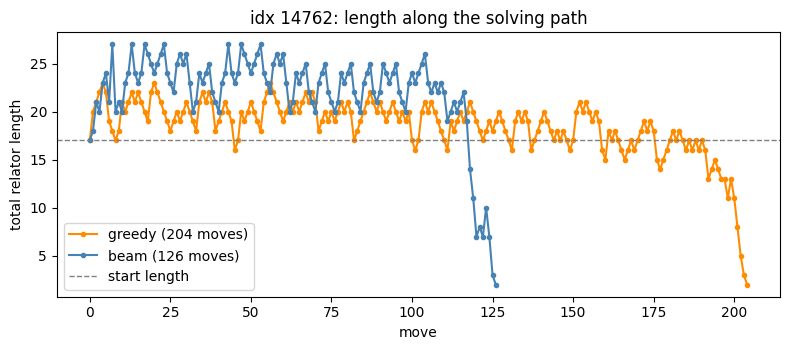

In [20]:
# pick a both-solved idx where beam is shorter AND beam climbs a hump, with the largest saving
cand = H[(H.delta_len > 0) & (H.k_hump > 0)].sort_values('delta_len', ascending=False)
ex = int(cand.index[0]) if len(cand) else int(H.index[0])
gL, kL = greedy_traj[ex], beam_traj[ex]
r1, r2 = initial[ex]
print(f'idx {ex}:  start = ({r1!r}, {r2!r})  start length {len(r1)+len(r2)}')
print(f'  greedy: {len(gL)-1} moves, max length {gL.max()}, hump {gL.max()-gL[0]}')
print(f'  beam  : {len(kL)-1} moves, max length {kL.max()}, hump {kL.max()-kL[0]}')

plt.figure(figsize=(8, 3.6))
plt.plot(range(len(gL)), gL, '-o', ms=3, color='darkorange', label=f'greedy ({len(gL)-1} moves)')
plt.plot(range(len(kL)), kL, '-o', ms=3, color='steelblue', label=f'beam ({len(kL)-1} moves)')
plt.axhline(gL[0], color='gray', ls='--', lw=1, label='start length')
plt.xlabel('move'); plt.ylabel('total relator length'); plt.title(f'idx {ex}: length along the solving path')
plt.legend(); plt.tight_layout(); plt.show()

## 7b. Seeing run-up on real paths: the biggest climb starts in a valley

Three beam paths chosen so their biggest climb happens *below* the start length — exactly the case `## 5.`'s
peak-minus-start metric scores as "no hump (0)." This is the `## 5c.` run-up idea on concrete paths.

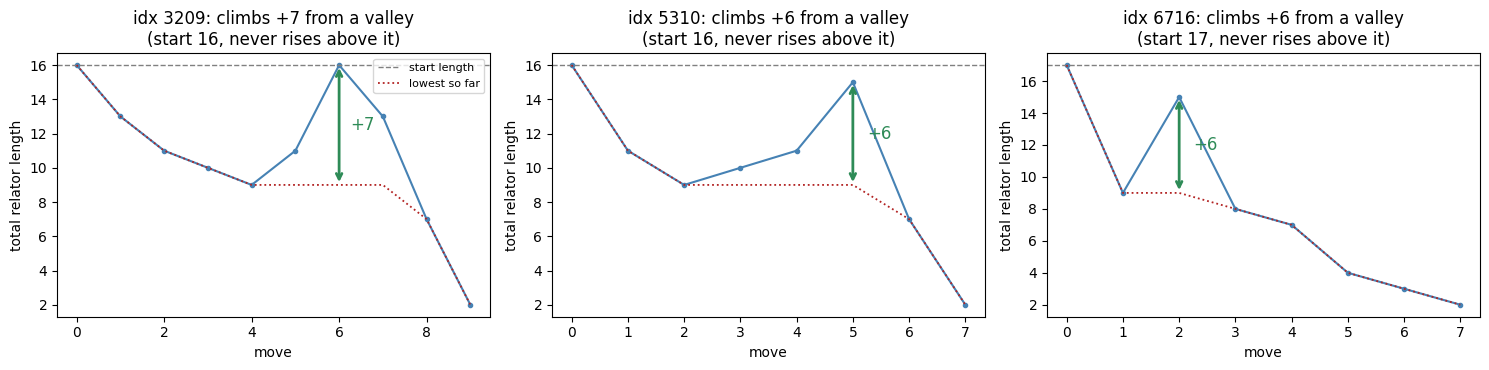

In [21]:
# beam paths whose biggest climb happens BELOW the start length (start-hump = 0, run-up large)
EX = [3209, 5310, 6716]
fig, ax = plt.subplots(1, len(EX), figsize=(15, 3.8))
for a, i in zip(ax, EX):
    L = np.asarray(beam_traj[i]); cm = np.minimum.accumulate(L); ru = L - cm
    tp = int(ru.argmax()); peak = int(L[tp]); floor = int(cm[tp]); runup = peak - floor
    a.plot(range(len(L)), L, '-o', ms=3, color='steelblue')
    a.axhline(L[0], color='gray', ls='--', lw=1, label='start length')
    a.plot(range(len(L)), cm, ls=':', color='firebrick', lw=1.3, label='lowest so far')
    a.annotate('', xy=(tp, peak), xytext=(tp, floor),
               arrowprops=dict(arrowstyle='<->', color='seagreen', lw=2))
    a.text(tp + 0.25, (peak + floor) / 2, f'+{runup}', color='seagreen', fontsize=12, va='center')
    a.set_title(f'idx {i}: climbs +{runup} from a valley\n(start {int(L[0])}, never rises above it)')
    a.set_xlabel('move'); a.set_ylabel('total relator length')
ax[0].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

**What this figure shows.** Each panel is one beam solving path (total length per move). Dashed grey = the
start length; dotted red = the lowest length reached so far; the green arrow is the **max run-up** (the
biggest climb out of a valley).

**What you can see.** In all three the words *never get longer than the start*, so `## 5.`'s "peak − start"
metric records hump 0 — yet the search clearly makes a deliberate **+6 / +7** climb out of a valley to
escape and finish.

**What it suggests.** Length-increasing moves matter *mid-search*, not only as an initial over-the-top
hump. A useful distance heuristic must understand that climbing *back up* from a low state can be the way
forward — it can't just reward "shorter." (Compare `## 7.` / idx 14762, where the climbing is instead
sustained across the whole first half of a long path.)

## 7c. All 12,670 paths in one view

The single paths above are great for intuition, but there are 12,670 of them — drawn raw it would be solid
spaghetti. The trick is a **common feature to align them**: stretch every solving path to the same width
(0% = its start, 100% = trivial), then colour each point by **how many paths pass through that
(progress, length) point**. That stacks the whole population into one picture — bright = where most paths
are — with the cyan median path drawn on top. Greedy and beam side by side, same axes.

median total length at  start / 25% / 50% / 75% / end  of the path:
  greedy: [17.  13.2 11.   5.7  2. ]
  beam  : [17.  15.3 12.8  6.8  2. ]   <- beam holds the words longer through the middle


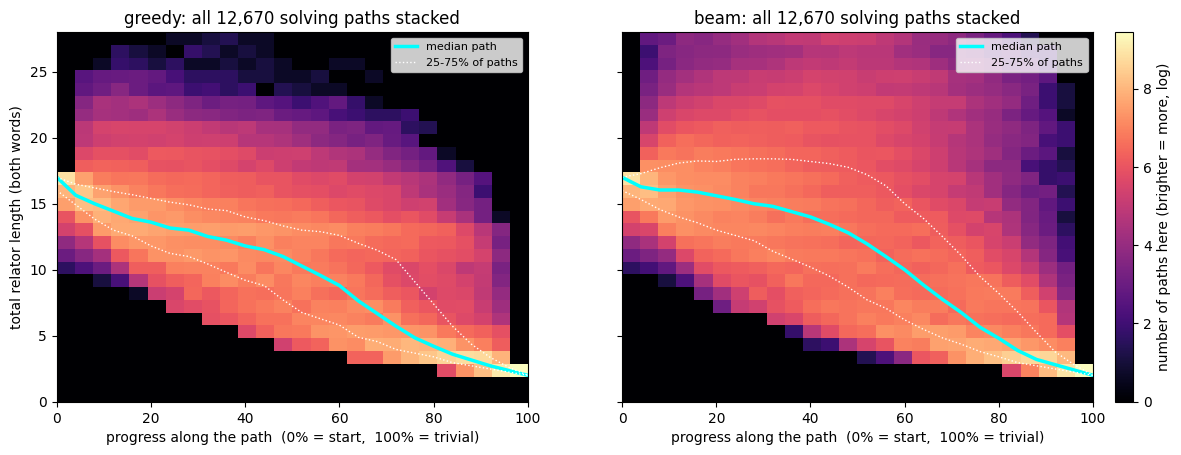

In [22]:
# stack ALL both-solved paths: stretch each to a common width, density of (progress, length)
NB = 25; prog = np.linspace(0, 1, NB + 1); LMAX = 28
def _resample(L):
    L = np.asarray(L, float)
    return np.interp(prog, np.linspace(0, 1, len(L)), L) if len(L) > 1 else np.full(NB + 1, L[0])
def _density(tl_list):
    R = np.array([_resample(L) for L in tl_list]); h = np.zeros((LMAX + 1, NB + 1))
    for col in range(NB + 1):
        for v in np.clip(np.rint(R[:, col]).astype(int), 0, LMAX):
            h[v, col] += 1
    return h, np.median(R, 0), np.percentile(R, 25, 0), np.percentile(R, 75, 0)

hg, mg, g25, g75 = _density([greedy_traj[i] for i in H.index])
hb, mb, b25, b75 = _density([beam_traj[i] for i in H.index])
sel = [0, NB // 4, NB // 2, 3 * NB // 4, NB]
print('median total length at  start / 25% / 50% / 75% / end  of the path:')
print(f'  greedy: {np.round(mg[sel], 1)}')
print(f'  beam  : {np.round(mb[sel], 1)}   <- beam holds the words longer through the middle')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for a, (h, med, p25, p75, who) in zip(ax, [(hg, mg, g25, g75, 'greedy'), (hb, mb, b25, b75, 'beam')]):
    im = a.imshow(np.log1p(h), origin='lower', aspect='auto', cmap='magma', extent=[0, 100, 0, LMAX])
    a.plot(prog * 100, med, color='cyan', lw=2.5, label='median path')
    a.plot(prog * 100, p25, color='white', lw=1, ls=':')
    a.plot(prog * 100, p75, color='white', lw=1, ls=':', label='25-75% of paths')
    a.set_title(f'{who}: all {len(H):,} solving paths stacked')
    a.set_xlabel('progress along the path  (0% = start,  100% = trivial)')
    a.legend(loc='upper right', fontsize=8)
ax[0].set_ylabel('total relator length (both words)')
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('number of paths here (brighter = more, log)')
plt.show()

**What this figure shows.** Every both-solved path from each method, stacked into one density map.
Brightness = how many paths sit at that length and that stage; the cyan line is the typical (median) path,
dotted white = the middle 50% of paths.

**What you can see.** Greedy's bright mass slides **straight downhill** — its median falls steadily from 17
to 2. Beam's bright mass and median **stay high through the first ~40%** (median ~15 where greedy is already
~13), and its upper band bulges *above the start length* before everything plunges to trivial at the end.
This is the `## 5b.`/`## 5c.` story at the scale of the whole dataset.

**What it suggests.** "Shorter = closer to solved" is true for greedy almost by construction, but plainly
false for the beam population — which is exactly the regime where a learned distance heuristic should beat
relator length.

## 8. Takeaways

From this pilot (12,670 presentations solved by both methods):

- **Beam is a strict improver, not an explorer here** (`## 3.`). It found 0 *new* solves, but a
  **shorter path on ~58%** of the shared ones, tied ~31%, cutting total moves ~27%.
- **Beam climbs, greedy descends** (`## 5.`). 74% of greedy paths never lengthen the words; beam grows
  them on 60%, and climbs 11+ extra letters on 1,173 presentations vs greedy's 9.
- **Climbing pays off** (`## 5b.`). The higher beam climbs, the more moves it saves — from +0.4 moves at
  hump 0 up to **+18 moves (shorter 96% of the time)** at hump 11+.
- **The climb is bigger than "peak − start" shows** (`## 5c.`, `## 7b.`). Measured from the lowest point
  reached (max run-up), ~44% of greedy paths and ~38% of beam paths climb *back up out of a valley* that
  the start-relative view misses — so even greedy climbs locally, just much less.
- **Beam commits, greedy nibbles** (`## 5d.`). Beam's biggest single continuous climb averages 3.8 letters
  (single jumps up to +13) vs greedy's 1.5; beam climbs in *fewer, larger* moves.
- **Seen across all 12,670 at once** (`## 7c.`): greedy's mass slides straight downhill; beam's stays
  elevated through the first ~40% of the path, then plunges — the population-level signature of the climb.
- **One concrete case** (`## 7.`): idx 14762 — beam climbs to length 27 and finishes in 126 moves; greedy
  stays low and takes 204.

Implication for the d-o-t model: relator length alone is a bad distance signal exactly on these hump and
run-up states (length goes *up* — even from a valley — while true distance goes *down*), which is why we
want to learn `f(presentation) -> distance`.